In [1]:

from collections.abc import Iterator
from dataclasses import dataclass

import torch
from torch import Tensor
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor


@dataclass(slots=True, frozen=True)
class CifarItem:
    image: Tensor # (3, 32, 32)
    label: Tensor # (,)


class CifarDataset:
    images: Tensor  # (N, 3, 32, 32)
    labels: Tensor  # (N,)

    def __init__(self, root: str = 'data/'):
        dataset = CIFAR10(root=root, download=True, transform=ToTensor())

        # Preload all data into memory as tensors
        self.images = torch.stack([dataset[i][0] for i in range(len(dataset))])  # (N, 3, 32, 32)
        self.labels = torch.tensor([dataset[i][1] for i in range(len(dataset))])  # (N,)

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, index: int) -> CifarItem:
        return CifarItem(image=self.images[index], label=self.labels[index])

    def __iter__(self) -> Iterator[CifarItem]:
        for i in range(len(self)):
            yield self[i]



In [2]:
import random

from apriori.ico.core.source import IcoSource

batch_size = 8
train_split_ratio = 0.02 # make it 10% of real dataset size for speed up in demo.

dataset = CifarDataset()
dataset_size = len(dataset)
all_indices = list(range(dataset_size))
random.shuffle(all_indices)

train_split = int(dataset_size * train_split_ratio)
train_source = IcoSource[int](lambda: all_indices[:train_split], name="CIFAR10 train indices")
train_source.describe()


──────────────────────────────────────── Flow plan: CIFAR10 train indices ─────────────────────────────────────────

 Flow                                               Signature                     Name                             
 📚IcoSource(<lambda>, size=1000)                   () → Iterator[int]            CIFAR10 train indices           

In [3]:
from collections.abc import Iterator

from apriori.ico.core.batcher import IcoBatcher
from apriori.ico.core.operator import IcoOperator


def shuffle_indices(indices: Iterator[int]) -> Iterator[int]:
    indices_list = list(indices)
    random.shuffle(indices_list)
    yield from indices_list


def fetch_item(index: int) -> CifarItem:
    return dataset[index]


batcher = IcoBatcher[CifarItem](batch_size=batch_size)

train_data_flow = train_source | IcoOperator(shuffle_indices) | IcoOperator(fetch_item).stream() | batcher
train_data_flow.name = "Train Input Flow"
train_data_flow.describe()

─────────────────────────────────────────── Flow plan: Train Input Flow ───────────────────────────────────────────

 Flow                                Signature                                               Name                  
 📚IcoSource(<lambda>, size=1000)    () → Iterator[int]                                      CIFAR10 train indices 
 shuffle_indices                     Iterator[int] → Iterator[int]                                                 
 ╭── for each in 🎞️ IcoStream()       Iterator[int] → Iterator[CifarItem]                                           
 │   fetch_item                      int → CifarItem                                                               
 ╰─▸ yield                           Iterator[CifarItem]                                                           
 📦IcoBatcher(batch_size=8)          Iterator[CifarItem] → Iterator[Iterator[CifarItem]]     batcher(8)           

Number of items in batch: 8


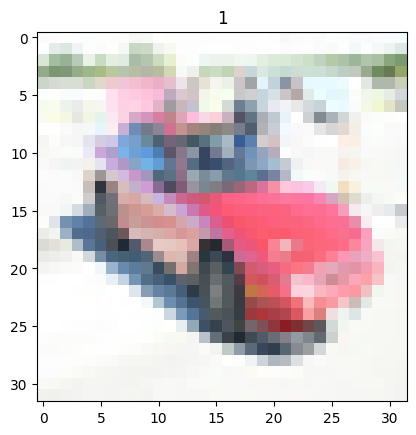

In [4]:
from matplotlib import pyplot as plt

for item_batch in train_data_flow(None):
    items = list(item_batch)
    print(f'Number of items in batch: {len(items)}')

    item = items[0]
    image = item.image.detach().cpu().numpy().transpose(1, 2, 0)
    label = item.label.item()

    plt.plot()
    plt.title(label)
    plt.imshow(image)

    break


In [5]:
from abc import ABC, abstractmethod

from torchvision.transforms import functional as F

from apriori.ico.core.operator import IcoOperator


class CifarTransform(ABC):
    p: float
    factor: float

    def __init__(self, p: float = 1.0, factor: float = 1.0):
        self.p = p
        self.factor = factor

    @abstractmethod
    def _image_transform(self, image: Tensor, factor: float) -> Tensor:
        raise NotImplementedError

    def __call__(self, item: CifarItem) -> CifarItem:
        if torch.rand(1) >= self.p:
            return item

        return CifarItem(
            image=self._image_transform(item.image, self.factor),
            label=item.label
        )

class HorizontalFlip(CifarTransform):
    def _image_transform(self, image: Tensor, factor: float) -> Tensor:
        return F.hflip(image)


class VerticalFlip(CifarTransform):
    def _image_transform(self, image: Tensor, factor: float) -> Tensor:
        return F.vflip(image)


class AdjustBrightness(CifarTransform):
    def _image_transform(self, image: Tensor, factor: float) -> Tensor:
        return F.adjust_brightness(image, factor)


class AdjustContrast(CifarTransform):
    def _image_transform(self, image: Tensor, factor: float) -> Tensor:
        return F.adjust_contrast(image, factor)


item_aug_flow = (
    IcoOperator(HorizontalFlip())
    | IcoOperator(VerticalFlip())
    | IcoOperator(AdjustBrightness(factor=0.2))
    | IcoOperator(AdjustContrast(factor=0.2))
)
item_aug_flow.name = "Item augmentation flow"
item_aug_flow.describe()




──────────────────────────────────────── Flow plan: Item augmentation flow ────────────────────────────────────────

 Flow                                           Signature                                             Name         
 HorizontalFlip()                               CifarItem → CifarItem                                              
 VerticalFlip()                                 CifarItem → CifarItem                                              
 AdjustBrightness()                             CifarItem → CifarItem                                              
 AdjustContrast()                               CifarItem → CifarItem                                             

In [6]:
from apriori.ico.core.pipeline import IcoPipeline

item_aug_flow = IcoPipeline(
    HorizontalFlip(),
    VerticalFlip(),
    AdjustBrightness(),
    AdjustContrast(),
    name="Item augmentation flow",
)
item_aug_flow.describe()

──────────────────────────────────────── Flow plan: Item augmentation flow ────────────────────────────────────────

 Flow                                           Signature                                             Name         
 HorizontalFlip()                               CifarItem → CifarItem                                              
 VerticalFlip()                                 CifarItem → CifarItem                                              
 AdjustBrightness()                             CifarItem → CifarItem                                              
 AdjustContrast()                               CifarItem → CifarItem                                             

In [7]:
from typing import final


@final
class CifarBatch:
    __slots__ = ('images', 'labels')

    images: Tensor  # (B, 3, 32, 32)
    labels: Tensor  # (B,)

    def __init__(self, items: Iterator[CifarItem]):
        items_list = list(items)
        self.images = torch.stack([item.image for item in items_list])  # (B, 3, 32, 32)
        self.labels = torch.tensor([item.label for item in items_list])  # (B,)


def collate(items: Iterator[CifarItem]) -> CifarBatch:
    return CifarBatch(items)


aug_flow = item_aug_flow.stream() | IcoOperator(collate)
aug_flow.name = "Full Augmentation flow"
aug_flow.describe()

──────────────────────────────────────── Flow plan: Full Augmentation flow ────────────────────────────────────────

 Flow                                         Signature                                                     Name   
 ╭── for each in 🎞️ IcoStream()                Iterator[CifarItem] → Iterator[CifarItem]                            
 │   HorizontalFlip()                         CifarItem → CifarItem                                                
 │   VerticalFlip()                           CifarItem → CifarItem                                                
 │   AdjustBrightness()                       CifarItem → CifarItem                                                
 │   AdjustContrast()                         CifarItem → CifarItem                                                
 ╰─▸ yield                                    Iterator[CifarItem]                                                  
 collate                                      Iterator[CifarItem] → CifarBatch                                    

In [8]:
full_train_data_flow = train_data_flow | aug_flow.stream()
full_train_data_flow.name = "Full Train Data Flow with Augmentation"
full_train_data_flow.describe()

──────────────────────────────── Flow plan: Full Train Data Flow with Augmentation ────────────────────────────────

 Flow                                Signature                                               Name                  
 📚IcoSource(<lambda>, size=1000)    () → Iterator[int]                                      CIFAR10 train indices 
 shuffle_indices                     Iterator[int] → Iterator[int]                                                 
 ╭── for each in 🎞️ IcoStream()       Iterator[int] → Iterator[CifarItem]                                           
 │   fetch_item                      int → CifarItem                                                               
 ╰─▸ yield                           Iterator[CifarItem]                                                           
 📦IcoBatcher(batch_size=8)          Iterator[CifarItem] → Iterator[Iterator[CifarItem]]     batcher(8)            
 ╭── for each in 🎞️ IcoStream()       Iterator[Iterator[CifarItem]] → Iterator[CifarBatch]                          
 │   ╭── for each in 🎞️ IcoStream()   Iterator[CifarItem] → Iterator[CifarItem]                                     
 │   │   HorizontalFlip()            CifarItem → CifarItem                                                         
 │   │   VerticalFlip()              CifarItem → CifarItem                                                         
 │   │   AdjustBrightness()          CifarItem → CifarItem                                                         
 │   │   AdjustContrast()            CifarItem → CifarItem                                                         
 │   ╰─▸ yield                       Iterator[CifarItem]                                                           
 │   collate                         Iterator[CifarItem] → CifarBatch                                              
 ╰─▸ yield                           Iterator[CifarBatch]

Batch images shape: torch.Size([8, 3, 32, 32]), Batch labels shape: torch.Size([8])


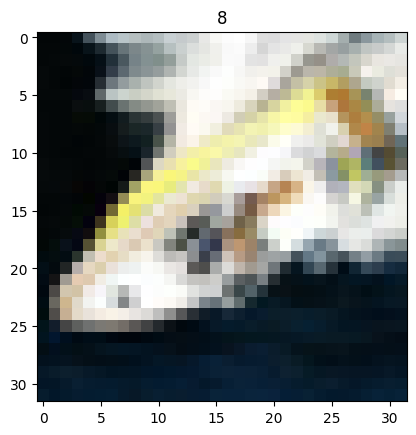

In [9]:
for batch in full_train_data_flow(None):
    print(f'Batch images shape: {batch.images.shape}, Batch labels shape: {batch.labels.shape}')

    image = batch.images[0].detach().cpu().numpy().transpose(1, 2, 0)
    label = batch.labels[0].item()

    plt.plot()
    plt.title(label)
    plt.imshow(image)
    break

In [10]:
import torch.nn as nn
from torchvision.models import resnet18


def create_cifar10_resnet18(num_classes: int = 10):
    model = resnet18()
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, num_classes)
    return model

model = create_cifar10_resnet18()
outputs = model(batch.images)
print(f"Outputs shape: {outputs.shape}")

Outputs shape: torch.Size([8, 10])


In [11]:
from dataclasses import dataclass

import torch

from apriori.ico.core.context_pipeline import IcoContextPipeline


@dataclass(slots=True)
class CifarContext:
    model: nn.Module
    optimizer: torch.optim.Optimizer
    loss_fn: torch.nn.Module = torch.nn.CrossEntropyLoss()
    iter_num: int = 0
    total_loss: float = 0.0


def train_step(batch: CifarBatch, context: CifarContext) -> CifarContext:
    context.optimizer.zero_grad()

    outputs = context.model(batch.images)
    loss = context.loss_fn(outputs, batch.labels)
    loss.backward()
    context.optimizer.step()

    context.total_loss = loss.item()
    context.iter_num += 1
    return context


def logging_step(context: CifarContext) -> CifarContext:
    if context.iter_num % 10 == 0:
        print(f"Iteration {context.iter_num}, Loss: {context.total_loss:.4f}")
    return context

def save_checkpoint_step(context: CifarContext) -> CifarContext:
    if context.iter_num % 100 == 0:
        print(f"Checkpointing model at iteration {context.iter_num}")
    return context



train_pipeline = IcoContextPipeline(
    train_step,
    logging_step,
    save_checkpoint_step
)
train_pipeline.name = "Training Pipeline"
train_pipeline.describe()


────────────────────────────────────────── Flow plan: Training Pipeline ───────────────────────────────────────────

 Flow                                 Signature                                                            Name    
 train_step                           CifarBatch, CifarContext → CifarContext                                      
 logging_step                         CifarContext → CifarContext                                                  
 save_checkpoint_step                 CifarContext → CifarContext                                                 

In [12]:
from apriori.ico.core.epoch import IcoEpoch

def start_train(context: CifarContext) -> CifarContext:
    context.model.train()
    return context


train_epoch = IcoEpoch(
    source=full_train_data_flow,
    context_operator=train_pipeline,
)
train_epoch.name = "Training Epoch"

train_flow = IcoOperator(start_train) | train_epoch
train_flow.name = "Train Flow"
train_flow.describe()



────────────────────────────────────────────── Flow plan: Train Flow ──────────────────────────────────────────────

 Flow                                   Signature                                             Name                 
 start_train                            CifarContext → CifarContext                                                
 🧠IcoEpoch()                           Iterator[CifarBatch], CifarContext → CifarContext     Training Epoch       
 ╭── for each in                        Iterator[CifarBatch]                                                       
 │   📚IcoSource(<lambda>, size=1000)   () → Iterator[int]                                    CIFAR10 train indic… 
 │   shuffle_indices                    Iterator[int] → Iterator[int]                                              
 │   ╭── for each in 🎞️ IcoStream()      Iterator[int] → Iterator[CifarItem]                                        
 │   │   fetch_item                     int → CifarItem                                                            
 │   ╰─▸ yield                          Iterator[CifarItem]                                                        
 │   📦IcoBatcher(batch_size=8)         Iterator[CifarItem] → Iterator[Iterator[CifarItem]]   batcher(8)           
 │   ╭── for each in 🎞️ IcoStream()      Iterator[Iterator[CifarItem]] → Iterator[CifarBatch]                       
 │   │   ╭── for each in 🎞️ IcoStream()  Iterator[CifarItem] → Iterator[CifarItem]                                  
 │   │   │   HorizontalFlip()           CifarItem → CifarItem                                                      
 │   │   │   VerticalFlip()             CifarItem → CifarItem                                                      
 │   │   │   AdjustBrightness()         CifarItem → CifarItem                                                      
 │   │   │   AdjustContrast()           CifarItem → CifarItem                                                      
 │   │   ╰─▸ yield                      Iterator[CifarItem]                                                        
 │   │   collate                        Iterator[CifarItem] → CifarBatch                                           
 │   ╰─▸ yield                          Iterator[CifarBatch]                                                       
 ├─▸ apply                              CifarBatch, CifarContext                                                   
 │   train_step                         CifarBatch, CifarContext → CifarContext                                    
 │   logging_step                       CifarContext → CifarContext                                                
 │   save_checkpoint_step               CifarContext → CifarContext                                                
 ╰─▸ emit                               CifarContext

In [13]:
model = create_cifar10_resnet18()

context = CifarContext(
    model=model,
    optimizer=torch.optim.Adam(model.parameters(), lr=0.01),
    loss_fn=torch.nn.CrossEntropyLoss(),
)


context_epoch1 = train_flow(context)

Iteration 10, Loss: 5.7188
Iteration 20, Loss: 4.0657
Iteration 30, Loss: 1.9911
Iteration 40, Loss: 3.0929
Iteration 50, Loss: 2.4942
Iteration 60, Loss: 2.2666
Iteration 70, Loss: 2.1378
Iteration 80, Loss: 2.4160
Iteration 90, Loss: 2.2885
Iteration 100, Loss: 2.1246
Checkpointing model at iteration 100
Iteration 110, Loss: 2.2968
Iteration 120, Loss: 2.2051


In [14]:
val_split_ratio = 0.02
val_split = int(dataset_size * val_split_ratio)
val_source = IcoSource[int](lambda: all_indices[-val_split:], name="CIFAR10 evaluation indices")


val_data_flow = val_source | IcoOperator(fetch_item).stream()
val_data_flow.name = "Validation Flow"
val_data_flow.describe()



─────────────────────────────────────────── Flow plan: Validation Flow ────────────────────────────────────────────

 Flow                                    Signature                                  Name                           
 📚IcoSource(<lambda>, size=1000)        () → Iterator[int]                         CIFAR10 evaluation indices     
 ╭── for each in 🎞️ IcoStream()           Iterator[int] → Iterator[CifarItem]                                       
 │   fetch_item                          int → CifarItem                                                           
 ╰─▸ yield                               Iterator[CifarItem]

In [15]:
from dataclasses import dataclass

from apriori.ico.core.context_operator import IcoContextOperator


@dataclass(slots=True)
class CifarEvalContext:
    train_context: CifarContext
    accuracy: float = 0.0
    total_samples: int = 0


def calculate_accuracy(item: CifarItem, context: CifarEvalContext) -> CifarEvalContext:
    with torch.no_grad():
        outputs = context.train_context.model(item.image.unsqueeze(0)) # (1, 10)

        predicted = torch.argmax(outputs, dim=1)
        correct = (predicted.item() == item.label)
        context.total_samples += 1
        context.accuracy += int(correct)

    return context


val_epoch = IcoEpoch(
    source=val_data_flow,
    context_operator=IcoContextOperator(calculate_accuracy),
    name = "Validation Epoch"
)
val_epoch.describe()


─────────────────────────────────────────── Flow plan: Validation Epoch ───────────────────────────────────────────

 Flow                               Signature                                              Name                    
 🧠IcoEpoch()                       Iterator[CifarItem], CifarEvalContext → CifarEvalCon…  Validation Epoch        
 ╭── for each in                    Iterator[CifarItem]                                                            
 │   📚IcoSource(<lambda>, size=1…  () → Iterator[int]                                     CIFAR10 evaluation ind… 
 │   ╭── for each in 🎞️ IcoStream()  Iterator[int] → Iterator[CifarItem]                                            
 │   │   fetch_item                 int → CifarItem                                                                
 │   ╰─▸ yield                      Iterator[CifarItem]                                                            
 ├─▸ apply                          CifarItem, CifarEvalContext                                                    
 │   calculate_accuracy             CifarItem, CifarEvalContext → CifarEvalContext                                 
 ╰─▸ emit                           CifarEvalContext

In [16]:
def start_eval(context: CifarContext) -> CifarEvalContext:
    context.model.eval()
    return CifarEvalContext(train_context=context)


def log_accuracy(context: CifarEvalContext) -> CifarEvalContext:
    accuracy = context.accuracy / context.total_samples if context.total_samples > 0 else 0.0
    print(f"Validation Accuracy: {accuracy * 100:.2f}% ({context.accuracy}/{context.total_samples})")
    return context


def end_eval(context: CifarEvalContext) -> CifarContext:
    return context.train_context


val_flow = IcoOperator(start_eval) | val_epoch | IcoOperator(log_accuracy) | IcoOperator(end_eval)
val_flow.name = "Validation Flow"
val_flow.describe()

─────────────────────────────────────────── Flow plan: Validation Flow ────────────────────────────────────────────

 Flow                               Signature                                              Name                    
 start_eval                         CifarContext → CifarEvalContext                                                
 🧠IcoEpoch()                       Iterator[CifarItem], CifarEvalContext → CifarEvalCon…  Validation Epoch        
 ╭── for each in                    Iterator[CifarItem]                                                            
 │   📚IcoSource(<lambda>, size=1…  () → Iterator[int]                                     CIFAR10 evaluation ind… 
 │   ╭── for each in 🎞️ IcoStream()  Iterator[int] → Iterator[CifarItem]                                            
 │   │   fetch_item                 int → CifarItem                                                                
 │   ╰─▸ yield                      Iterator[CifarItem]                                                            
 ├─▸ apply                          CifarItem, CifarEvalContext                                                    
 │   calculate_accuracy             CifarItem, CifarEvalContext → CifarEvalContext                                 
 ╰─▸ emit                           CifarEvalContext                                                               
 log_accuracy                       CifarEvalContext → CifarEvalContext                                            
 end_eval                           CifarEvalContext → CifarContext                                               

In [17]:
epoch_flow = train_flow | val_flow
epoch_flow.name = "Train and Validation Epoch Flow"
epoch_flow.describe()


─────────────────────────────────── Flow plan: Train and Validation Epoch Flow ────────────────────────────────────

 Flow                                Signature                                             Name                    
 start_train                         CifarContext → CifarContext                                                   
 🧠IcoEpoch()                        Iterator[CifarBatch], CifarContext → CifarContext     Training Epoch          
 ╭── for each in                     Iterator[CifarBatch]                                                          
 │   📚IcoSource(<lambda>, size=10…  () → Iterator[int]                                    CIFAR10 train indices   
 │   shuffle_indices                 Iterator[int] → Iterator[int]                                                 
 │   ╭── for each in 🎞️ IcoStream()   Iterator[int] → Iterator[CifarItem]                                           
 │   │   fetch_item                  int → CifarItem                                                               
 │   ╰─▸ yield                       Iterator[CifarItem]                                                           
 │   📦IcoBatcher(batch_size=8)      Iterator[CifarItem] → Iterator[Iterator[CifarItem]]   batcher(8)              
 │   ╭── for each in 🎞️ IcoStream()   Iterator[Iterator[CifarItem]] → Iterator[CifarBatch]                          
 │   │   ╭── for each in 🎞️ IcoStre…  Iterator[CifarItem] → Iterator[CifarItem]                                     
 │   │   │   HorizontalFlip()        CifarItem → CifarItem                                                         
 │   │   │   VerticalFlip()          CifarItem → CifarItem                                                         
 │   │   │   AdjustBrightness()      CifarItem → CifarItem                                                         
 │   │   │   AdjustContrast()        CifarItem → CifarItem                                                         
 │   │   ╰─▸ yield                   Iterator[CifarItem]                                                           
 │   │   collate                     Iterator[CifarItem] → CifarBatch                                              
 │   ╰─▸ yield                       Iterator[CifarBatch]                                                          
 ├─▸ apply                           CifarBatch, CifarContext                                                      
 │   train_step                      CifarBatch, CifarContext → CifarContext                                       
 │   logging_step                    CifarContext → CifarContext                                                   
 │   save_checkpoint_step            CifarContext → CifarContext                                                   
 ╰─▸ emit                            CifarContext                                                                  
 start_eval                          CifarContext → CifarEvalContext                                               
 🧠IcoEpoch()                        Iterator[CifarItem], CifarEvalContext → CifarEvalCo…  Validation Epoch        
 ╭── for each in                     Iterator[CifarItem]                                                           
 │   📚IcoSource(<lambda>, size=10…  () → Iterator[int]                                    CIFAR10 evaluation ind… 
 │   ╭── for each in 🎞️ IcoStream()   Iterator[int] → Iterator[CifarItem]                                           
 │   │   fetch_item                  int → CifarItem                                                               
 │   ╰─▸ yield                       Iterator[CifarItem]                                                           
 ├─▸ apply                           CifarItem, CifarEvalContext                                                   
 │   calculate_accuracy              CifarItem, CifarEvalContext → CifarEvalContext                                
 ╰─▸ emit                            CifarEvalContext                                                              
 log_accuracy                        CifarEvalContext → C

In [18]:
epoch1_context = epoch_flow(context)


Iteration 130, Loss: 2.3195
Iteration 140, Loss: 2.1856
Iteration 150, Loss: 2.1673
Iteration 160, Loss: 2.0443
Iteration 170, Loss: 2.5761
Iteration 180, Loss: 2.5105
Iteration 190, Loss: 2.3962
Iteration 200, Loss: 2.2454
Checkpointing model at iteration 200
Iteration 210, Loss: 2.0901
Iteration 220, Loss: 2.3256
Iteration 230, Loss: 2.0278
Iteration 240, Loss: 2.5406
Iteration 250, Loss: 2.2654
Validation Accuracy: 12.90% (129.0/1000)


In [19]:
from apriori.ico.core.process import IcoProcess

train_process = IcoProcess(epoch_flow, num_iterations=5)
train_process.name = "CIFAR-10 Training Process"
train_process.describe()




────────────────────────────────────── Flow plan: CIFAR-10 Training Process ───────────────────────────────────────

 Flow                                  Signature                                             Name                  
 ╭── iterate in 🔁IcoProcess(num_ite…  CifarContext → CifarContext                           CIFAR-10 Training Pr… 
 │   start_train                       CifarContext → CifarContext                                                 
 │   🧠IcoEpoch()                      Iterator[CifarBatch], CifarContext → CifarContext     Training Epoch        
 │   ╭── for each in                   Iterator[CifarBatch]                                                        
 │   │   📚IcoSource(<lambda>, size=…  () → Iterator[int]                                    CIFAR10 train indices 
 │   │   shuffle_indices               Iterator[int] → Iterator[int]                                               
 │   │   ╭── for each in 🎞️ IcoStream…  Iterator[int] → Iterator[CifarItem]                                         
 │   │   │   fetch_item                int → CifarItem                                                             
 │   │   ╰─▸ yield                     Iterator[CifarItem]                                                         
 │   │   📦IcoBatcher(batch_size=8)    Iterator[CifarItem] → Iterator[Iterator[CifarItem]]   batcher(8)            
 │   │   ╭── for each in 🎞️ IcoStream…  Iterator[Iterator[CifarItem]] → Iterator[CifarBatch]                        
 │   │   │   ╭── for each in 🎞️ IcoSt…  Iterator[CifarItem] → Iterator[CifarItem]                                   
 │   │   │   │   HorizontalFlip()      CifarItem → CifarItem                                                       
 │   │   │   │   VerticalFlip()        CifarItem → CifarItem                                                       
 │   │   │   │   AdjustBrightness()    CifarItem → CifarItem                                                       
 │   │   │   │   AdjustContrast()      CifarItem → CifarItem                                                       
 │   │   │   ╰─▸ yield                 Iterator[CifarItem]                                                         
 │   │   │   collate                   Iterator[CifarItem] → CifarBatch                                            
 │   │   ╰─▸ yield                     Iterator[CifarBatch]                                                        
 │   ├─▸ apply                         CifarBatch, CifarContext                                                    
 │   │   train_step                    CifarBatch, CifarContext → CifarContext                                     
 │   │   logging_step                  CifarContext → CifarContext                                                 
 │   │   save_checkpoint_step          CifarContext → CifarContext                                                 
 │   ╰─▸ emit                          CifarContext                                                                
 │   start_eval                        CifarContext → CifarEvalContext                                             
 │   🧠IcoEpoch()                      Iterator[CifarItem], CifarEvalContext → CifarEvalCo…  Validation Epoch      
 │   ╭── for each in                   Iterator[CifarItem]                                                         
 │   │   📚IcoSource(<lambda>, size=…  () → Iterator[int]                                    CIFAR10 evaluation i… 
 │   │   ╭── for each in 🎞️ IcoStream…  Iterator[int] → Iterator[CifarItem]                                         
 │   │   │   fetch_item                int → CifarItem                                                             
 │   │   ╰─▸ yield                     Iterator[CifarItem]                                                         
 │   ├─▸ apply                         CifarItem, CifarEvalContext                                                 
 │   │   calculate_accuracy            CifarItem, CifarEvalContext → CifarEvalContext                              
 │   ╰─▸ emit                          CifarEvalContext   

In [20]:
final_context = train_process(context)


Iteration 260, Loss: 2.2370
Iteration 270, Loss: 2.1628
Iteration 280, Loss: 2.2259
Iteration 290, Loss: 2.2537
Iteration 300, Loss: 2.3485
Checkpointing model at iteration 300
Iteration 310, Loss: 2.0773
Iteration 320, Loss: 2.0623
Iteration 330, Loss: 2.4946
Iteration 340, Loss: 2.0393
Iteration 350, Loss: 1.7487
Iteration 360, Loss: 2.1630
Iteration 370, Loss: 1.9513
Validation Accuracy: 17.20% (172.0/1000)
Iteration 380, Loss: 1.8438
Iteration 390, Loss: 1.9417
Iteration 400, Loss: 2.1819
Checkpointing model at iteration 400
Iteration 410, Loss: 2.0294
Iteration 420, Loss: 2.0825
Iteration 430, Loss: 2.1397
Iteration 440, Loss: 2.2003
Iteration 450, Loss: 1.9382
Iteration 460, Loss: 1.8303
Iteration 470, Loss: 2.0811
Iteration 480, Loss: 2.1755
Iteration 490, Loss: 2.0850
Iteration 500, Loss: 2.0646
Checkpointing model at iteration 500
Validation Accuracy: 16.80% (168.0/1000)
Iteration 510, Loss: 1.9655
Iteration 520, Loss: 2.0551
Iteration 530, Loss: 2.2225
Iteration 540, Loss: 2.